In [1]:
defe

NameError: name 'defe' is not defined

In [1]:
import sys
sys.path.append('..')
from sqlalchemy import create_engine, text
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from geoalchemy2 import Geometry
from shapely.geometry import LineString

from config import RUTA_UNIDAD_ONE_DRIVE
from config import RUTA_LOCAL_ONE_DRIVE
from config import API_AMIGOCLOUD_TOKEN_ADM
from config import POSTGRES_UTEA

POSTGRES_UTEA['DATABASE'] = 'utea_precision'

In [2]:
PATH_SHPS = RUTA_UNIDAD_ONE_DRIVE + r"\Ingenio Azucarero Guabira S.A\UTEA - SEMANAL - PROGRAMA DE COSECHA\2026\SEGUIMIENTO_COSECHA\SHP_RECORRIDOS"

In [3]:
def obtener_engine():
    return create_engine(
        f"postgresql+psycopg2://{POSTGRES_UTEA['USER']}:{POSTGRES_UTEA['PASSWORD']}@{POSTGRES_UTEA['HOST']}:{POSTGRES_UTEA['PORT']}/{POSTGRES_UTEA['DATABASE']}"
    )

def obtener_archivos_db():
    query = text(f"SELECT nombre_archivo FROM datos_cosecha.registro_de_archivos")
    try:
        engine = obtener_engine()
        with engine.connect() as conn:
            result = conn.execute(query)
            # Retornamos un set para búsquedas O(1) en Python
            return [row[0] for row in result]
    except Exception as e:
        print(f"Error al consultar la tabla de registro: {e}")
        return []

def obtener_archivos_locales():
    try:
        # Listamos archivos que terminen en .shp y sean archivos (no carpetas)
        archivos_shp = [
            archivo for archivo in os.listdir(PATH_SHPS) 
            if archivo.lower().endswith('.shp') and os.path.isfile(os.path.join(PATH_SHPS, archivo))
        ]
        return archivos_shp
    except FileNotFoundError:
        print(f"Error: La ruta '{PATH_SHPS}' no existe.")
        return []
    except Exception as e:
        print(f"Error al leer la carpeta: {e}")
        return []

def cargar_archivo_local(ruta_shp):
    gdf = gpd.read_file(ruta_shp)
    gdf['IsoTime'] = pd.to_datetime(gdf['IsoTime'])
    #gdf.columns = [c.lower() for c in gdf.columns]
    gdf.columns = gdf.columns.str.lower()
    gdf = gdf.rename(columns={'geometry': 'geom'})
    gdf = gdf.set_geometry('geom')
    gdf = gdf.to_crs(epsg=32720)
    columnas_db = ['distance',
                   'swathwidth',
                   'vryldrcane',
                   'sectionid',
                   'crop',
                   'trash',
                   'time',
                   'heading',
                   'variety',
                   'elevation',
                   'isotime',
                   'machine',
                   'fuel',
                   'vehiclspee',
                   'producthas', 
                   'geom']
    gdf = gdf[columnas_db].copy()
    return gdf

def obtener_id_lote(conn, nombre_archivo):
    """Busca el ID de la tabla maestra usando el nombre del archivo."""
    try:
        query = text("""
            SELECT id FROM datos_cosecha.fechas 
            WHERE nombre_archivo = :nom_file
        """)
        res = conn.execute(query, {'nom_file': nombre_archivo}).fetchone()
        return res[0] if res else None
    except (IndexError, ValueError):
        return None

def cargar_puntos_shps(ruta_carpeta):
    """Función principal que coordina la lectura y carga a Postgres."""
    engine = obtener_engine()
    pendientes = obtener_lotes_pendientes() # Tu función que filtra puntos_cargados IS FALSE
    for nombre_archivo in pendientes:
        ruta_shp = os.path.join(ruta_carpeta, f"{nombre_archivo}.shp")
        if not os.path.exists(ruta_shp):
            print(f"⚠️ Archivo no encontrado: {nombre_archivo}")
            continue
        try:
            with engine.begin() as conn:
                # 1. Identificar el lote
                lote_id = obtener_id_lote(conn, nombre_archivo)
                if lote_id is None:
                    print(f"❌ No existe registro maestro para: {nombre_archivo}")
                    continue
                # 2. Preparar los datos
                df_final = preparar_geodataframe_utm(ruta_shp, lote_id)
                # 3. Insertar detalles
                df_final.to_postgis(
                    'recorridos_cosecha', 
                    conn, 
                    schema='datos_cosecha', 
                    if_exists='append'
                )
                # 4. Actualizar estado
                conn.execute(text("""
                    UPDATE datos_cosecha.fechas 
                    SET puntos_cargados = TRUE 
                    WHERE id = :id
                """), {'id': lote_id})
                print(f"✅ {nombre_archivo}: {len(df_final)} puntos cargados.")
        except Exception as e:
            print(f"❌ Error procesando {nombre_archivo}: {str(e)}")

In [78]:
archivos_procesados = obtener_archivos_db()
print('Lista de archivos procesados en base de datos:', len(archivos_procesados))

Lista de archivos procesados en base de datos: 1


In [79]:
archivos_locales = obtener_archivos_locales()
print('Lista de archivos en carpera local:', len(archivos_locales))

Lista de archivos en carpera local: 2


In [80]:
archivos_pendientes = list(set(archivos_locales) - set(archivos_procesados))

In [81]:
archivos_pendientes

['2026-04-27.shp']

In [66]:
for archivo in archivos_pendientes:
    #ruta_shp = os.path.join(PATH_SHPS, archivo)
    #cargar_archivo_local(ruta_shp)

SyntaxError: incomplete input (1655564365.py, line 3)

In [82]:
archivo = archivos_pendientes[0]

In [83]:
ruta_shp = os.path.join(PATH_SHPS, archivo)

In [84]:
recorridos_shp = cargar_archivo_local(ruta_shp)

<Axes: >

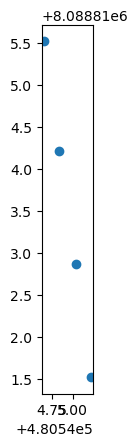

In [85]:
recorridos_shp.plot()

In [86]:
# 1. Preparación: Convertir a datetime y ordenar cronológicamente
recorridos_shp['isotime'] = pd.to_datetime(recorridos_shp['isotime'])
recorridos_shp = recorridos_shp.sort_values('isotime').reset_index(drop=True)
# 2. Creamos una columna auxiliar con la geometría del punto ANTERIOR
recorridos_shp['prev_geom'] = recorridos_shp['geom'].shift(1)
# 3. Filtramos la primera fila (ya que no tiene un punto anterior para formar una línea)
df_segmentos = recorridos_shp.dropna(subset=['prev_geom']).copy()
# 4. Generamos los segmentos (LineString) uniendo el punto anterior con el actual
# Al hacerlo así, la fila mantiene sus datos originales (los del punto de destino)
df_segmentos['geom'] = df_segmentos.apply(
    lambda x: LineString([x['prev_geom'], x['geom']]), axis=1
)
# 5. Limpieza: Eliminamos la columna auxiliar
df_segmentos = df_segmentos.drop(columns=['prev_geom'])

<Axes: >

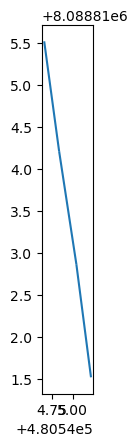

In [87]:
df_segmentos.plot()

In [88]:
df_segmentos['distancia_real'] = df_segmentos.geom.length
df_segmentos['diferencia_distancia'] = (df_segmentos['distance'] - df_segmentos['distancia_real']).abs()

In [89]:
df_segmentos

,distance,swathwidth,vryldrcane,sectionid,crop,trash,time,heading,variety,elevation,isotime,machine,fuel,vehiclspee,producthas,geom,distancia_real,diferencia_distancia
1,1.356263,1.5,131.482657,4417,133,28.52,5/30/2025 6:19:15 PM,351.999644,85-22,277.135677,2025-05-30 18:19:15.667000+00:00,1,0.015108,4.903039,a783dfe8,"LINESTRING (480545.219 8088811.522, 480545.045...",1.356354,0.000090
2,1.357263,1.5,127.790457,4417,133,21.32,5/30/2025 6:19:16 PM,351.282212,85-22,277.117677,2025-05-30 18:19:16.666000+00:00,1,0.014591,4.914559,a783dfe8,"LINESTRING (480545.045 8088812.867, 480544.840...",1.358570,0.001306
3,1.318263,1.5,109.559753,4417,133,26.60,5/30/2025 6:19:17 PM,351.299642,85-22,277.115677,2025-05-30 18:19:17.672000+00:00,1,0.014663,4.804399,a783dfe8,"LINESTRING (480544.840 8088814.210, 480544.662...",1.318456,0.000193


In [90]:
def registrar_log_archivo(nombre_archivo, cantidad_filas):
    query = text("""
        INSERT INTO datos_cosecha.registro_de_archivos 
        (nombre_archivo, fecha_registro, cantidad_registros)
        VALUES (:nombre, CURRENT_DATE, :cantidad)
    """)
    try:
        engine = obtener_engine()
        with engine.begin() as conn:
            conn.execute(query, {"nombre": nombre_archivo, "cantidad": cantidad_filas})
        return True
    except Exception as e:
        print(f"Error al registrar el log del archivo: {e}")
        return False

In [91]:
def insertar_datos_cosecha(gdf, nombre_archivo):
    if gdf.empty:
        print("El GeoDataFrame está vacío.")
        return
    # 1. Nombre de la tabla temporal
    temp_table = "temp_recorrido_cosechadora"
    try:
        engine = obtener_engine()
        with engine.begin() as conn:
            # 2. Cargar el GDF a una tabla temporal (sin las restricciones de la original)
            # Usamos if_exists='replace' para asegurar que la temporal esté limpia
            gdf.to_postgis(temp_table, conn, if_exists='replace', index=False)
            # 3. Insertar desde la temporal a la real usando ON CONFLICT DO NOTHING
            # Esto valida contra el UNIQUE CONSTRAINT (machine, isotime)
            query = text(f"""
                INSERT INTO datos_cosecha.recorrido_cosechadora 
                (distance, swathwidth, vryldrcane, sectionid, crop, trash, time, 
                 heading, variety, elevation, isotime, machine, fuel, 
                 vehiclspee, producthas, distancia_real, diferencia_distancia, geom)
                SELECT 
                    distance, swathwidth, vryldrcane, sectionid, crop, trash, time, 
                    heading, variety, elevation, isotime, machine, fuel, 
                    vehiclspee, producthas, distancia_real, diferencia_distancia, geom
                FROM {temp_table}
                ON CONFLICT (machine, isotime) DO NOTHING;
            """)
            result = conn.execute(query)
            # 4. Eliminar la tabla temporal
            conn.execute(text(f"DROP TABLE IF EXISTS {temp_table}"))
        registrar_log_archivo(nombre_archivo, len(gdf))
        print(f"Inserción completada. Filas procesadas: {len(gdf)}")
        return True
    except Exception as e:
        print(f"Error durante la inserción: {e}")
        return False

In [92]:
estado = insertar_datos_cosecha(df_segmentos, archivo)
print(estado)

Inserción completada. Filas procesadas: 3
True


In [ ]:
lotes_faltantes = obtener_lotes_pendientes()

print(f"Se encontraron {len(lotes_faltantes)} recorridos sin procesar:")
lotes_faltantes

In [ ]:
cargar_puntos_shps(PATH_SHPS)

In [ ]:
ruta_shp = os.path.join(PATH_SHPS, f"2026-04-23.shp")

In [ ]:
ruta_shp

In [ ]:
res = preparar_geodataframe_utm(ruta_shp, 1)

In [ ]:
res.plot()

In [ ]:
res

In [ ]:
df = res.copy()

In [ ]:
# 1. Preparación: Convertir a datetime y ordenar cronológicamente
df['isotime'] = pd.to_datetime(df['isotime'])
df = df.sort_values('isotime').reset_index(drop=True)
# 2. Creamos una columna auxiliar con la geometría del punto ANTERIOR
df['prev_geom'] = df['geom'].shift(1)
# 3. Filtramos la primera fila (ya que no tiene un punto anterior para formar una línea)
df_segmentos = df.dropna(subset=['prev_geom']).copy()
# 4. Generamos los segmentos (LineString) uniendo el punto anterior con el actual
# Al hacerlo así, la fila mantiene sus datos originales (los del punto de destino)
df_segmentos['geom'] = df_segmentos.apply(
    lambda x: LineString([x['prev_geom'], x['geom']]), axis=1
)
# 5. Limpieza: Eliminamos la columna auxiliar
df_segmentos = df_segmentos.drop(columns=['prev_geom'])

In [ ]:
df_segmentos['distancia_real'] = df_segmentos.geom.length
df_segmentos['diferencia_distancia'] = (df_segmentos['distance'] - df_segmentos['distancia_real']).abs()

In [ ]:
df_segmentos = df_segmentos[df_segmentos['diferencia_distancia'] < 3]

In [ ]:
df_segmentos.plot()

In [ ]:
df_segmentos

In [ ]:
# 1. Filtramos por la fecha que deseas analizar (ajusta la fecha)
fecha_interes = '2025-06-01'
df_dia = df_segmentos[df_segmentos['isotime'].dt.date == pd.to_datetime(fecha_interes).date()].copy()

# 2. Extraemos el minuto del día (0 a 1439)
# Esto convierte la hora/minuto en un índice lineal
df_dia['minuto_dia'] = df_dia['isotime'].dt.hour * 60 + df_dia['isotime'].dt.minute

# 3. Creamos un array de ceros para todo el día (1440 minutos)
actividad = np.zeros(1440)

# 4. Marcamos con 1 los minutos donde hubo registros
minutos_con_datos = df_dia['minuto_dia'].unique()
actividad[minutos_con_datos] = 1

# 5. Graficamos
plt.figure(figsize=(15, 2))
# Usamos imshow para crear una "cinta" de actividad
plt.imshow(actividad.reshape(1, -1), aspect='auto', cmap='Greens', interpolation='nearest')

# Configuración estética del eje X (Horas)
plt.xticks(np.arange(0, 1441, 60), [f'{h:02d}:00' for h in range(25)], rotation=45)
plt.yticks([]) # Ocultamos el eje Y ya que es una sola fila
plt.title(f'Actividad de la Cosechadora - {fecha_interes}')
plt.xlabel('Hora del día')
plt.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Definir el inicio y fin del periodo
fecha_interes = '2025-05-31'
inicio_periodo = pd.to_datetime(f'{fecha_interes} 06:00:00').tz_localize('UTC') # Ajusta el TZ si es necesario
fin_periodo = inicio_periodo + pd.Timedelta(days=1)

# 2. Filtrar el GeoDataFrame
df_turno = df_segmentos[(df_segmentos['isotime'] >= inicio_periodo) & 
                        (df_segmentos['isotime'] < fin_periodo)].copy()

# 3. Calcular los minutos transcurridos desde las 06:00 AM
# Esto nos da un índice de 0 a 1439
df_turno['minuto_relativo'] = (df_turno['isotime'] - inicio_periodo).dt.total_seconds() // 60
df_turno['minuto_relativo'] = df_turno['minuto_relativo'].astype(int)

# 4. Crear el array de actividad
actividad = np.zeros(1440)
minutos_con_datos = df_turno['minuto_relativo'].unique()
# Aseguramos que no se salga del índice por segundos extra
minutos_con_datos = minutos_con_datos[minutos_con_datos < 1440]
actividad[minutos_con_datos] = 1

# 5. Graficar
plt.figure(figsize=(15, 2))
plt.imshow(actividad.reshape(1, -1), aspect='auto', cmap='Greens', interpolation='nearest')

# Configuración de etiquetas del eje X para que empiecen a las 06:00
horas_labels = []
for h in range(25):
    hora_actual = (6 + h) % 24
    horas_labels.append(f'{hora_actual:02d}:00')

plt.xticks(np.arange(0, 1441, 60), horas_labels, rotation=45)
plt.yticks([])
plt.title(f'Actividad Cosechadora: {inicio_periodo.strftime("%d/%m %H:%M")} a {fin_periodo.strftime("%d/%m %H:%M")}')
plt.xlabel('Hora del Turno')
plt.grid(axis='x', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
df_segmentos['isotime'] = df_segmentos['isotime'].astype(str)

In [ ]:
df_segmentos.to_file("lineas.shp", driver="ESRI Shapefile")